In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('hospital_resources_multi.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['name', 'date'])

In [ ]:
le = LabelEncoder()
df['name_encoded'] = le.fit_transform(df['name'])

In [5]:
# This helps the model understand that Month 12 is next to Month 1
df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)
df['year'] = df['date'].dt.year


In [6]:
feature_cols = ['name_encoded', 'current_stock', 'month_sin', 'month_cos', 'year']
target_cols = ['min_required', 'max_required']

In [7]:
scaler_feat = MinMaxScaler()
scaler_targ = MinMaxScaler()

df_scaled_feat = scaler_feat.fit_transform(df[feature_cols])
df_scaled_targ = scaler_targ.fit_transform(df[target_cols])


In [ ]:
# Create Sequences (Sliding Window)
def create_sequences(feat_data, targ_data, seq_length=2):
    X, y = [], []
    if len(feat_data) <= seq_length:
        return np.array([]), np.array([])
        
    for i in range(len(feat_data) - seq_length):
        X.append(feat_data[i : i + seq_length])
        y.append(targ_data[i + seq_length])
    return np.array(X), np.array(y)


In [9]:
X_all, y_all = [], []
for name in df['name'].unique():
    mask = df['name'] == name
    X_s, y_s = create_sequences(df_scaled_feat[mask], df_scaled_targ[mask], seq_length=2)
    if X_s.size > 0:
        X_all.append(X_s)
        y_all.append(y_s)

X = np.concatenate(X_all)
y = np.concatenate(y_all)

In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [11]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True, activation='tanh'),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(2) 
])

In [12]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

In [13]:
history = model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=8, 
    validation_split=0.1, 
    verbose=1
)

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - loss: 0.1077 - mae: 0.2469 - val_loss: 0.0204 - val_mae: 0.1287
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0086 - mae: 0.0719 - val_loss: 0.0168 - val_mae: 0.1177
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0065 - mae: 0.0633 - val_loss: 0.0093 - val_mae: 0.0832
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0060 - mae: 0.0606 - val_loss: 0.0056 - val_mae: 0.0613
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0058 - mae: 0.0582 - val_loss: 0.0048 - val_mae: 0.0597
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0053 - mae: 0.0565 - val_loss: 0.0046 - val_mae: 0.0584
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0041 - mae: 0.0499 - val_loss: 0.0045 - val_mae: 0.0567
Epoch 8/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0043 - mae: 0.0510 - val_loss: 0.0062 - val_mae: 0.0668
Epoch 9/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/s

In [ ]:
# Evaluation
y_pred = model.predict(X_test)
y_pred_inv = scaler_targ.inverse_transform(y_pred)
y_test_inv = scaler_targ.inverse_transform(y_test)

print(f"Final Model MAE: {model.evaluate(X_test, y_test, verbose=0)[1]:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step
Final Model MAE: 0.0573


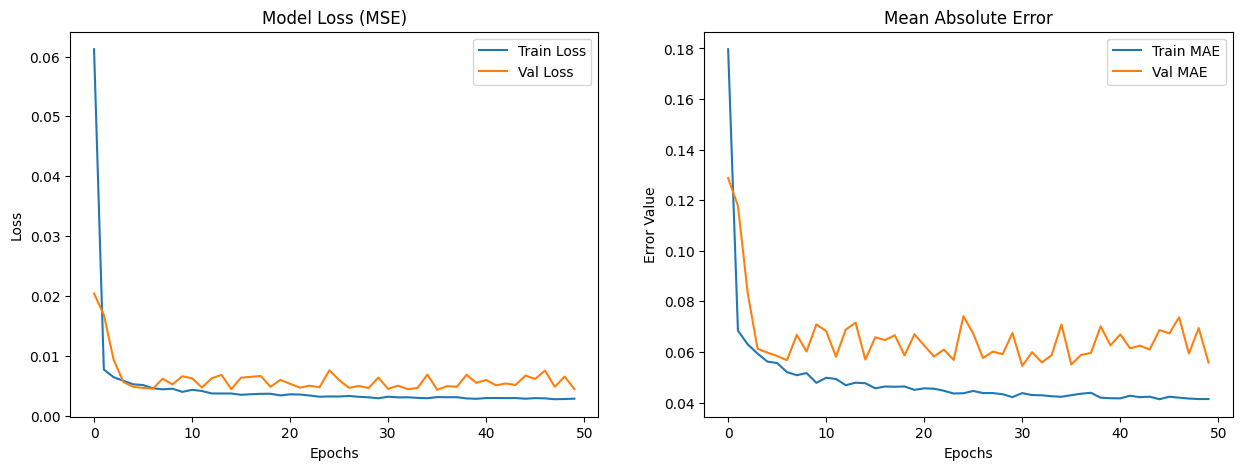

In [15]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss Plot
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Model Loss (MSE)')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # MAE Plot
    ax2.plot(history.history['mae'], label='Train MAE')
    ax2.plot(history.history['val_mae'], label='Val MAE')
    ax2.set_title('Mean Absolute Error')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Error Value')
    ax2.legend()
    
    plt.show()

plot_training_history(history)

In [ ]:

y_pred_scaled = model.predict(X_test)

# Reverse the scaling to get actual resource counts
y_pred_inv = scaler_targ.inverse_transform(y_pred_scaled)

y_test_inv = scaler_targ.inverse_transform(y_test)

print("Shape of transformed predictions:", y_pred_inv.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Shape of transformed predictions: (249, 2)


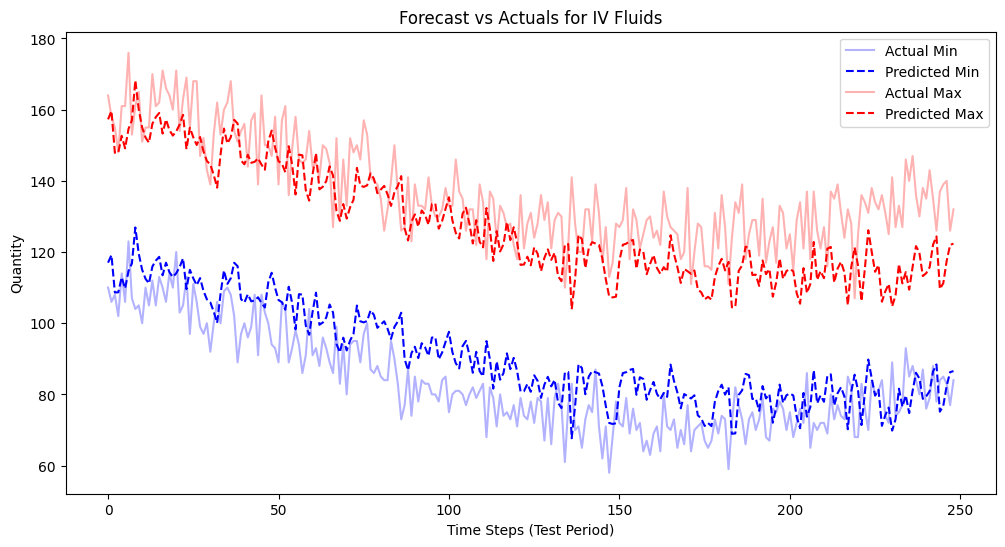

In [ ]:
def plot_resource_trend(resource_name, y_test_inv, y_pred_inv, le):
    resource_idx = le.transform([resource_name])[0]
    
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_inv[:, 0], 'b-', label='Actual Min', alpha=0.3)
    plt.plot(y_pred_inv[:, 0], 'b--', label='Predicted Min')
    
    plt.plot(y_test_inv[:, 1], 'r-', label='Actual Max', alpha=0.3)
    plt.plot(y_pred_inv[:, 1], 'r--', label='Predicted Max')
    
    plt.title(f'Forecast vs Actuals for {resource_name}')
    plt.ylabel('Quantity')
    plt.xlabel('Time Steps (Test Period)')
    plt.legend()
    plt.show()

plot_resource_trend(le.classes_[1], y_test_inv, y_pred_inv, le)